In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("airbnb_clean.csv", low_memory=False)
df.columns = df.columns.str.lower()

print(df.shape)
print(df["price"].describe())
print("median:", df["price"].median())
print(df.isna().sum()[df.isna().sum() > 0])

(74110, 29)
count    74110.000000
mean       160.373000
std        168.580536
min          5.000000
25%         75.000000
50%        111.000000
75%        185.000000
max       1999.000000
Name: price, dtype: float64
median: 111.0
first_review              15864
host_has_profile_pic        188
host_identity_verified      188
host_response_rate        18299
host_since                  188
last_review               15827
neighbourhood              6872
review_scores_rating      16722
bedrooms                     93
beds                        133
bathrooms                   200
dtype: int64


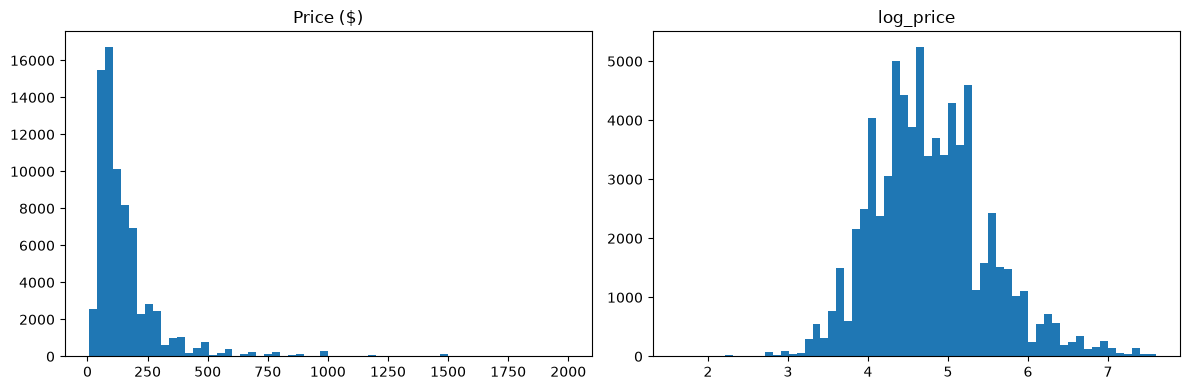

skew price: 4.3
skew log_price: 0.52


In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(df["price"], bins=60)
ax[0].set_title("Price ($)")
ax[1].hist(df["log_price"], bins=60)
ax[1].set_title("log_price")
plt.tight_layout()
plt.show()

print("skew price:", round(df["price"].skew(), 2))
print("skew log_price:", round(df["log_price"].skew(), 2))

In [4]:
num_cols = ["accommodates", "bedrooms", "beds", "bathrooms",
            "number_of_reviews", "review_scores_rating", "host_response_rate"]

corr = df[num_cols + ["log_price"]].corr(method="spearman")["log_price"]
print(corr.drop("log_price").sort_values(ascending=False).round(3))

accommodates            0.589
beds                    0.481
bedrooms                0.408
bathrooms               0.283
review_scores_rating    0.085
host_response_rate     -0.000
number_of_reviews      -0.033
Name: log_price, dtype: float64


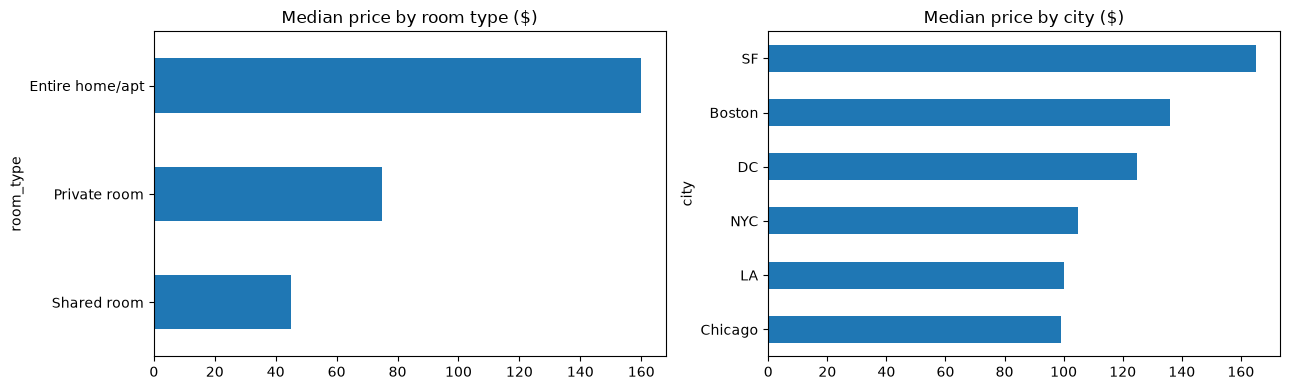

room_type
Shared room         45.0
Private room        75.0
Entire home/apt    160.0
Name: price, dtype: float64
city
Chicago     99.0
LA         100.0
NYC        105.0
DC         125.0
Boston     136.0
SF         165.0
Name: price, dtype: float64


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

room = df.groupby("room_type")["price"].median().sort_values()
city = df.groupby("city")["price"].median().sort_values()

room.plot(kind="barh", ax=ax[0], title="Median price by room type ($)")
city.plot(kind="barh", ax=ax[1], title="Median price by city ($)")

plt.tight_layout()
plt.show()

print(room)
print(city)

In [6]:
for c in ["property_type", "bed_type", "cancellation_policy", "city",
          "neighbourhood", "cleaning_fee", "instant_bookable"]:
    print(c, df[c].nunique())

print(df["property_type"].value_counts())

property_type 35
bed_type 5
cancellation_policy 5
city 6
neighbourhood 619
cleaning_fee 2
instant_bookable 2
property_type
Apartment             49003
House                 16511
Condominium            2657
Townhouse              1692
Loft                   1244
Other                   607
Guesthouse              498
Bed & Breakfast         462
Bungalow                366
Villa                   179
Dorm                    142
Guest suite             123
Camper/RV                94
Timeshare                77
Cabin                    72
In-law                   71
Hostel                   70
Boutique hotel           69
Boat                     65
Serviced apartment       21
Tent                     18
Castle                   13
Vacation home            11
Yurt                      9
Hut                       8
Treehouse                 7
Chalet                    6
Earth House               4
Tipi                      3
Train                     2
Cave                      2
Casa part

In [11]:
top_types = df["property_type"].value_counts()
top_types = top_types[top_types >= 400].index
df["property_group"] = df["property_type"].where(df["property_type"].isin(top_types), "Other")

df["amenities_count"] = df["amenities"].fillna("{}").apply(
    lambda s: 0 if s.strip("{} ") == "" else s.count(",") + 1
)

print(df["property_group"].value_counts())
print(df["amenities_count"].describe())

property_group
Apartment          49003
House              16511
Condominium         2657
Other               2043
Townhouse           1692
Loft                1244
Guesthouse           498
Bed & Breakfast      462
Name: count, dtype: int64
count    74110.000000
mean        17.594576
std          6.956426
min          0.000000
25%         13.000000
50%         17.000000
75%         22.000000
max         86.000000
Name: amenities_count, dtype: float64


In [12]:
from sklearn.model_selection import train_test_split

features = ["property_group", "room_type", "accommodates", "bedrooms", "beds",
            "bathrooms", "bed_type", "cancellation_policy", "cleaning_fee",
            "instant_bookable", "city", "latitude", "longitude", "amenities_count"]

X = df[features]
y = df["log_price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(59288, 14) (14822, 14)


In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

num_cols = ["accommodates", "bedrooms", "beds", "bathrooms",
            "latitude", "longitude", "amenities_count"]
cat_cols = ["property_group", "room_type", "bed_type", "cancellation_policy",
            "cleaning_fee", "instant_bookable", "city"]

X_train = X_train.copy()
X_test = X_test.copy()
X_train[cat_cols] = X_train[cat_cols].astype(str)
X_test[cat_cols] = X_test[cat_cols].astype(str)

preprocess = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num_cols),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("oh", OneHotEncoder(handle_unknown="ignore"))]), cat_cols),
])

def evaluate(name, model):
    pred_log = model.predict(X_test)
    pred, actual = np.exp(pred_log), np.exp(y_test)
    print(f"{name}: MAE ${mean_absolute_error(actual, pred):.2f} | "
          f"RMSE ${np.sqrt(mean_squared_error(actual, pred)):.2f} | "
          f"R2 (log) {r2_score(y_test, pred_log):.3f} | "
          f"R2 ($) {r2_score(actual, pred):.3f}")

baseline = Pipeline([("prep", preprocess), ("m", DummyRegressor(strategy="mean"))]).fit(X_train, y_train)
linear = Pipeline([("prep", preprocess), ("m", LinearRegression())]).fit(X_train, y_train)

evaluate("Baseline (average)", baseline)
evaluate("Linear Regression", linear)

Baseline (average): MAE $87.73 | RMSE $171.95 | R2 (log) -0.000 | R2 ($) -0.060
Linear Regression: MAE $59.17 | RMSE $126.36 | R2 (log) 0.579 | R2 ($) 0.428


In [28]:
from sklearn.ensemble import RandomForestRegressor

rf = Pipeline([
    ("prep", preprocess),
    ("m", RandomForestRegressor(n_estimators=200, min_samples_leaf=3,
                                n_jobs=-1, random_state=42))
]).fit(X_train, y_train)

evaluate("Random Forest", rf)

Random Forest: MAE $50.59 | RMSE $113.09 | R2 (log) 0.685 | R2 ($) 0.542


In [26]:
from sklearn.ensemble import HistGradientBoostingRegressor

preprocess_dense = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num_cols),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("oh", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cat_cols),
], sparse_threshold=0)

gb = Pipeline([
    ("prep", preprocess_dense),
    ("m", HistGradientBoostingRegressor(max_iter=300, learning_rate=0.1, random_state=42))
]).fit(X_train, y_train)

evaluate("Gradient Boosting", gb)

Gradient Boosting: MAE $49.99 | RMSE $111.56 | R2 (log) 0.693 | R2 ($) 0.554


In [29]:
from sklearn.model_selection import cross_validate

models = {"Linear": linear, "Random Forest": rf, "Gradient Boosting": gb}

for name, m in models.items():
    cv = cross_validate(m, X_train, y_train, cv=5,
                        scoring=["r2", "neg_mean_absolute_error"])
    print(f"{name}: CV R2 (log) {cv['test_r2'].mean():.3f} +/- {cv['test_r2'].std():.3f} | "
          f"CV MAE (log) {-cv['test_neg_mean_absolute_error'].mean():.3f}")

Linear: CV R2 (log) 0.567 +/- 0.006 | CV MAE (log) 0.353
Random Forest: CV R2 (log) 0.675 +/- 0.005 | CV MAE (log) 0.292
Gradient Boosting: CV R2 (log) 0.684 +/- 0.006 | CV MAE (log) 0.290


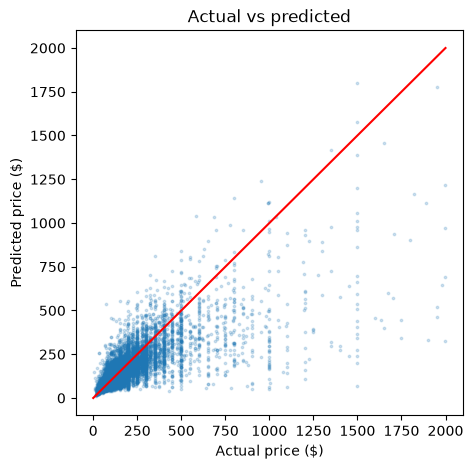

             listings    MAE  avg_bias
band                                  
(0, 50]          1297   20.1      19.8
(50, 100]        4992   19.9      11.7
(100, 150]       3104   29.3       5.9
(150, 250]       3532   46.7     -12.4
(250, 500]       1344  102.9     -67.5
(500, 2000]       553  399.9    -374.4


In [30]:
pred = np.exp(gb.predict(X_test))
actual = np.exp(y_test)

plt.figure(figsize=(5, 5))
plt.scatter(actual, pred, s=3, alpha=0.2)
plt.plot([0, 2000], [0, 2000], color="red")
plt.xlabel("Actual price ($)")
plt.ylabel("Predicted price ($)")
plt.title("Actual vs predicted")
plt.show()

df_err = pd.DataFrame({"actual": actual.values, "pred": pred})
df_err["band"] = pd.cut(df_err["actual"], [0, 50, 100, 150, 250, 500, 2000])
df_err["abs_err"] = (df_err["pred"] - df_err["actual"]).abs()
df_err["bias"] = df_err["pred"] - df_err["actual"]
print(df_err.groupby("band", observed=True).agg(
    listings=("actual", "size"), MAE=("abs_err", "mean"), avg_bias=("bias", "mean")).round(1))

In [31]:
from sklearn.inspection import permutation_importance

imp = permutation_importance(gb, X_test, y_test, n_repeats=5,
                             random_state=42, scoring="r2", n_jobs=-1)
print(pd.Series(imp.importances_mean, index=X_test.columns)
        .sort_values(ascending=False).round(4))

room_type              0.3006
longitude              0.2516
latitude               0.2467
accommodates           0.1103
bathrooms              0.0577
bedrooms               0.0380
property_group         0.0130
cleaning_fee           0.0106
amenities_count        0.0084
city                   0.0072
cancellation_policy    0.0070
beds                   0.0048
instant_bookable       0.0040
bed_type               0.0003
dtype: float64


In [32]:
import joblib
joblib.dump(gb, "pricing_model.joblib")

['pricing_model.joblib']

In [33]:
lo = Pipeline([("prep", preprocess_dense),
               ("m", HistGradientBoostingRegressor(loss="quantile", quantile=0.10,
                                                   max_iter=300, random_state=42))]).fit(X_train, y_train)
hi = Pipeline([("prep", preprocess_dense),
               ("m", HistGradientBoostingRegressor(loss="quantile", quantile=0.90,
                                                   max_iter=300, random_state=42))]).fit(X_train, y_train)

lo_p = np.exp(lo.predict(X_test))
hi_p = np.exp(hi.predict(X_test))

df_err["lo"], df_err["hi"] = lo_p, hi_p
df_err["inside"] = (df_err["actual"] >= df_err["lo"]) & (df_err["actual"] <= df_err["hi"])

print("overall coverage:", round(df_err["inside"].mean(), 3))
print("median range width: $", round(float(np.median(hi_p - lo_p)), 1))
print(df_err.groupby("band", observed=True)["inside"].mean().round(2))

overall coverage: 0.778
median range width: $ 92.2
band
(0, 50]        0.60
(50, 100]      0.83
(100, 150]     0.84
(150, 250]     0.81
(250, 500]     0.69
(500, 2000]    0.46
Name: inside, dtype: float64


In [34]:
def recommend_price(listing):
    row = pd.DataFrame([listing])
    row[cat_cols] = row[cat_cols].astype(str)
    est = float(np.exp(gb.predict(row[features])[0]))
    low = min(float(np.exp(lo.predict(row[features])[0])), est)
    high = max(float(np.exp(hi.predict(row[features])[0])), est)
    return round(est), round(low), round(high)

example = {
    "property_group": "Apartment", "room_type": "Entire home/apt",
    "accommodates": 4, "bedrooms": 2, "beds": 2, "bathrooms": 1,
    "bed_type": "Real Bed", "cancellation_policy": "strict",
    "cleaning_fee": True, "instant_bookable": False, "city": "NYC",
    "latitude": 40.7265, "longitude": -73.9815, "amenities_count": 18,
}
print(recommend_price(example))

(229, 154, 322)


In [20]:
def comparable_market(listing):
    c = df[(df["city"] == listing["city"]) &
           (df["room_type"] == listing["room_type"]) &
           (df["accommodates"].between(listing["accommodates"] - 1, listing["accommodates"] + 1)) &
           (df["bedrooms"] == listing["bedrooms"])]
    q = c["price"].quantile([0.25, 0.5, 0.75]).round(0).tolist()
    return len(c), q

print(comparable_market(example))

(2508, [140.0, 190.0, 250.0])


In [35]:
out = df.loc[X_test.index, ["id", "city", "room_type", "property_group",
                            "accommodates", "bedrooms", "bathrooms", "price"]].copy()
out["predicted_price"] = pred.round(2)
out["price_low"] = lo_p.round(2)
out["price_high"] = hi_p.round(2)
out["in_range"] = (out["price"] >= out["price_low"]) & (out["price"] <= out["price_high"])
out.to_csv("model_predictions.csv", index=False)
print(out.shape)

(14822, 12)


In [36]:
pd.DataFrame({"feature": X_test.columns, "importance": imp.importances_mean}) \
  .sort_values("importance", ascending=False) \
  .to_csv("feature_importance.csv", index=False)

In [37]:
evaluate("Gradient Boosting", gb)

Gradient Boosting: MAE $49.99 | RMSE $111.56 | R2 (log) 0.693 | R2 ($) 0.554
